# Trap Measurement Efficiency Diagnostics

This notebook is a standalone diagnostic workflow for understanding the structure in the measurement-efficiency curves. It keeps the paper notebook untouched and focuses on checking whether the short-`tau_e` feature is physical, a pooling artifact, or driven by fit-quality cuts.

The central question is whether the analysis efficiency should be treated as a one-dimensional curve `epsilon(tau_e)` or as a two-dimensional surface `epsilon(tau_e, T)`. The plots below are ordered to build that answer step by step.

Important definition: throughout this notebook, `efficiency` means an empirical analysis efficiency for the modeled trap sample. It is the probability that a characterized trap-temperature entry has a successful direct intensity fit at that temperature. It is not a pure hardware/protocol acceptance and it is not the absolute probability of detecting any physical trap in the CCD.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import beta

from utils import load_spectra_hdf5
from dipole import log_energy_cross_section

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['font.size'] = 14


In [2]:
measurement_temperatures = np.array([
    125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175,
    180, 183, 185, 187, 190, 193, 195, 197, 200, 203, 207, 210
])

fit_filename = 'fit_dipole_spectra_err_4.h5'
well_behaved_threshold = 4
target_temp = 135.0

# Fine bins reproduce the existing tau_at_<T> plots. Coarser bins are better for stable diagnostics.
fine_tau_bins = np.geomspace(1e-7, 1e8, 100)
coarse_tau_bins = np.geomspace(1e-7, 1e8, 45)

# The response maximum of exp(-t/tau) - exp(-8t/tau) occurs at t/tau = ln(8)/7.
response_x_peak = np.log(8.0) / 7.0


In [3]:
def jeffreys_interval(k, n, confidence_level=0.68):
    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)
    lo = np.full_like(k, np.nan, dtype=float)
    hi = np.full_like(k, np.nan, dtype=float)
    valid = n > 0
    alpha = 1.0 - confidence_level
    lo[valid] = beta.ppf(alpha / 2.0, k[valid] + 0.5, n[valid] - k[valid] + 0.5)
    hi[valid] = beta.ppf(1.0 - alpha / 2.0, k[valid] + 0.5, n[valid] - k[valid] + 0.5)
    return lo, hi

def efficiency_from_counts(measured_counts, total_counts, confidence_level=0.68):
    efficiency = np.divide(
        measured_counts,
        total_counts,
        out=np.full_like(total_counts, np.nan, dtype=float),
        where=total_counts > 0,
    )
    lo, hi = jeffreys_interval(measured_counts, total_counts, confidence_level=confidence_level)
    return efficiency, lo, hi

def is_characterized_trap(testdp):
    return (
        testdp.get('WellBehavedTrap', False)
        and not testdp.get('EnergyFitFailed', True)
        and testdp.get('GoodEnergyFit', False)
    )

def primary_rejection_reason(temp_record):
    if temp_record.get('GoodIntensityFit', False):
        return 'Good'
    if temp_record.get('IntensityFitFailed', False):
        return 'Fit failed'
    if temp_record.get('fit_p_value', 1.0) <= 0.05:
        return 'p <= 0.05'
    if 'fit_tau' in temp_record and 'fit_tau_err' in temp_record:
        if temp_record['fit_tau_err'] / temp_record['fit_tau'] > 0.5:
            return 'rel tau err > 0.5'
    if 'intensities' in temp_record and 'intensity_err' in temp_record:
        if np.max(temp_record['intensities']) < 3.0 * np.mean(temp_record['intensity_err']):
            return 'max < 3 mean err'
    if 'intensities' in temp_record and 'image_sigma' in temp_record:
        if np.max(temp_record['intensities']) < 3.0 * temp_record['image_sigma']:
            return 'max < 3 image sigma'
    return 'Other bad'

def rejection_flags(temp_record):
    flags = {
        'p <= 0.05': False,
        'rel tau err > 0.5': False,
        'max < 3 mean err': False,
        'max < 3 image sigma': False,
        'Fit failed': False,
        'Other bad': False,
    }
    if temp_record.get('GoodIntensityFit', False):
        return flags
    if temp_record.get('IntensityFitFailed', False):
        flags['Fit failed'] = True
        return flags
    if temp_record.get('fit_p_value', 1.0) <= 0.05:
        flags['p <= 0.05'] = True
    if 'fit_tau' in temp_record and 'fit_tau_err' in temp_record:
        flags['rel tau err > 0.5'] = temp_record['fit_tau_err'] / temp_record['fit_tau'] > 0.5
    if 'intensities' in temp_record and 'intensity_err' in temp_record:
        flags['max < 3 mean err'] = np.max(temp_record['intensities']) < 3.0 * np.mean(temp_record['intensity_err'])
    if 'intensities' in temp_record and 'image_sigma' in temp_record:
        flags['max < 3 image sigma'] = np.max(temp_record['intensities']) < 3.0 * temp_record['image_sigma']
    if not any(flags.values()):
        flags['Other bad'] = True
    return flags

def build_trap_records(fit_spectra, temperatures, target_temp=135.0):
    records = []
    for q in [0, 1, 2, 3]:
        for dp, testdp in fit_spectra[q].items():
            if type(dp) != tuple or not is_characterized_trap(testdp):
                continue
            energy = testdp['energy_BestFitEnergy']
            log_sigma = np.log(testdp['energy_BestFitCrossSection'])
            measured_temps = np.asarray(testdp['energy_temperatures'], dtype=float)
            tau_by_temp = np.exp(log_energy_cross_section(temperatures.astype(float), energy, log_sigma))
            tau_135 = np.exp(log_energy_cross_section(target_temp, energy, log_sigma))
            records.append({
                'quad': q,
                'coord': dp,
                'trap': testdp,
                'energy': energy,
                'log_sigma': log_sigma,
                'measured_temps': measured_temps,
                'tau_by_temp': tau_by_temp,
                'tau_135': tau_135,
            })
    return records

def build_efficiency_matrices(records, temperatures, bins):
    measured = np.zeros((len(temperatures), len(bins) - 1), dtype=int)
    total = np.zeros_like(measured)
    for record in records:
        for ti, temp in enumerate(temperatures):
            tau = record['tau_by_temp'][ti]
            bi = np.searchsorted(bins, tau, side='right') - 1
            if bi < 0 or bi >= len(bins) - 1:
                continue
            total[ti, bi] += 1
            if temp in record['measured_temps']:
                measured[ti, bi] += 1
    efficiency, lo, hi = efficiency_from_counts(measured, total)
    return measured, total, efficiency, lo, hi

def make_log_efficiency_function(bin_centers, efficiency, total_counts, min_total=20, eff_floor=0.05):
    valid = (total_counts >= min_total) & np.isfinite(efficiency) & (bin_centers > 0)
    if np.count_nonzero(valid) < 2:
        return None, valid
    x = np.log10(bin_centers[valid])
    y = np.clip(efficiency[valid], eff_floor, 1.0)
    order = np.argsort(x)
    interp = interp1d(x[order], y[order], bounds_error=False, fill_value=(y[order][0], y[order][-1]))
    def func(tau):
        tau = np.asarray(tau, dtype=float)
        out = np.full_like(tau, np.nan, dtype=float)
        valid_tau = tau > 0
        out[valid_tau] = interp(np.log10(tau[valid_tau]))
        return np.clip(out, eff_floor, 1.0)
    return func, valid

def poisson_binomial_at_least(probabilities, k_min):
    probabilities = np.asarray(probabilities, dtype=float)
    probabilities = probabilities[np.isfinite(probabilities)]
    if len(probabilities) < k_min:
        return 0.0
    pmf = np.array([1.0])
    for p in probabilities:
        p = np.clip(p, 0.0, 1.0)
        updated = np.zeros(len(pmf) + 1)
        updated[:-1] += pmf * (1.0 - p)
        updated[1:] += pmf * p
        pmf = updated
    return np.sum(pmf[k_min:])


## 1. Load the threshold-4 characterized sample

This is the same selection used in the current paper workflow: `WellBehavedTrap`, no failed energy fit, and `GoodEnergyFit`.

Why start here: the efficiency correction should be defined relative to traps that are comparable under the same `tau(T)` model. Traps that fail the model or do not have enough good temperature points are not directly comparable in `tau_e(135 K)`, so including them in the denominator would mix different populations.

How to read the output: `Characterized traps` is the number of traps entering the final modeled sample. The median number of measured temperatures tells us how much temperature information a typical fitted trap has. If this number is low, then corrections based on global characterization probability can be sensitive to the selection threshold.

In [4]:
fit_spectra = load_spectra_hdf5(fit_filename)
records = build_trap_records(fit_spectra, measurement_temperatures, target_temp=target_temp)
print(f'Loaded {fit_filename}')
print(f'Characterized traps in this sample: {len(records)}')
print(f'Median number of measured temperatures: {np.median([len(r["measured_temps"]) for r in records]):.1f}')


Loaded fit_dipole_spectra_err_4.h5
Characterized traps in this sample: 2135
Median number of measured temperatures: 5.0


## 2. Check the measurement protocol window

If the only limitation were the `t_ph` scan, the efficient tau range should roughly track `tau = t_ph / (ln(8)/7)`.

Why this matters: the fitted intensity model is `I(t_ph) = A [exp(-t_ph/tau) - exp(-8 t_ph/tau)]`. This response is largest when `t_ph/tau = ln(8)/7`, so a delay scan from `t_ph_min` to `t_ph_max` should be most sensitive to approximately `tau_min = t_ph_min / (ln(8)/7)` through `tau_max = t_ph_max / (ln(8)/7)`.

Expected behavior: if efficiency were controlled only by the protocol, every temperature with the same `t_ph` grid should have a similar efficiency shape. Temperatures with the longer `t_ph_max = 1.03 s` grid should extend to larger tau than temperatures that only go to `0.167 s`.

Takeaway to look for: if the measured efficiency curves have strong temperature-to-temperature differences inside the same nominal protocol window, then the efficiency is not just a function of `tau_e`; it also depends on temperature-dependent analysis or image-quality effects.

In [5]:
tph_grids = {}
for temp in measurement_temperatures:
    for record in records:
        trap = record['trap']
        if temp in trap and 'seconds' in trap[temp]:
            tph_grids[temp] = np.asarray(trap[temp]['seconds'], dtype=float)
            break

print('T  n_tph  min_tph  max_tph  tau_at_min_peak  tau_at_max_peak')
for temp in measurement_temperatures:
    seconds = tph_grids.get(temp)
    if seconds is None:
        continue
    print(f'{temp:3d} {len(seconds):6d} {seconds.min():8.3g} {seconds.max():8.3g} {seconds.min()/response_x_peak:14.3g} {seconds.max()/response_x_peak:14.3g}')


T  n_tph  min_tph  max_tph  tau_at_min_peak  tau_at_max_peak
125     18    5e-05    0.167       0.000168          0.561
130     18    5e-05    0.167       0.000168          0.561
135     18    5e-05    0.167       0.000168          0.561
140     18    5e-05    0.167       0.000168          0.561
145     18    5e-05    0.167       0.000168          0.561
150     18    5e-05    0.167       0.000168          0.561
155     18    5e-05    0.167       0.000168          0.561
160     18    5e-05    0.167       0.000168          0.561
165     18    5e-05    0.167       0.000168          0.561
170     18    5e-05    0.167       0.000168          0.561
175     18    5e-05    0.167       0.000168          0.561
180     25    5e-05     1.03       0.000168           3.48
183     25    5e-05     1.03       0.000168           3.48
185     18    5e-05    0.167       0.000168          0.561
187     25    5e-05     1.03       0.000168           3.48
190     25    5e-05     1.03       0.000168           

## 3. Per-temperature efficiency curves

These plots show one efficiency curve per selected temperature. Each point is `N_measured / N_total` in a tau bin, where `N_measured` is the number of characterized trap-temperature entries with a direct good intensity fit at that temperature and `N_total` is all characterized trap-temperature entries whose fitted `tau(T)` lands in that bin.

Why make this plot: the pooled efficiency curve in the paper-style workflow collapses all temperatures into one curve. If the short-tau mini peak is physical and only depends on `tau_e`, it should appear consistently at the same tau in these individual temperature panels. If it moves, appears only at some temperatures, or changes amplitude strongly, then pooling is creating or exaggerating structure.

How to read it: the orange band is the approximate protocol window where the response peak can be sampled by the available `t_ph` values. Points outside this band are expected to have low efficiency. Points inside this band should be high only if the signal is strong enough and the fitted intensity curve passes all quality cuts.

Why Jeffreys intervals: the previous symmetric error formula gave zero error bars when efficiency was exactly 0 or 1. These intervals keep finite uncertainty in low-count edge bins, which is essential when diagnosing apparent peaks.

Main takeaway: strong differences between neighboring temperatures, such as 160 K and 170 K, indicate that the measured efficiency is not purely protocol-driven. It includes temperature-specific fit-quality and image/noise effects.

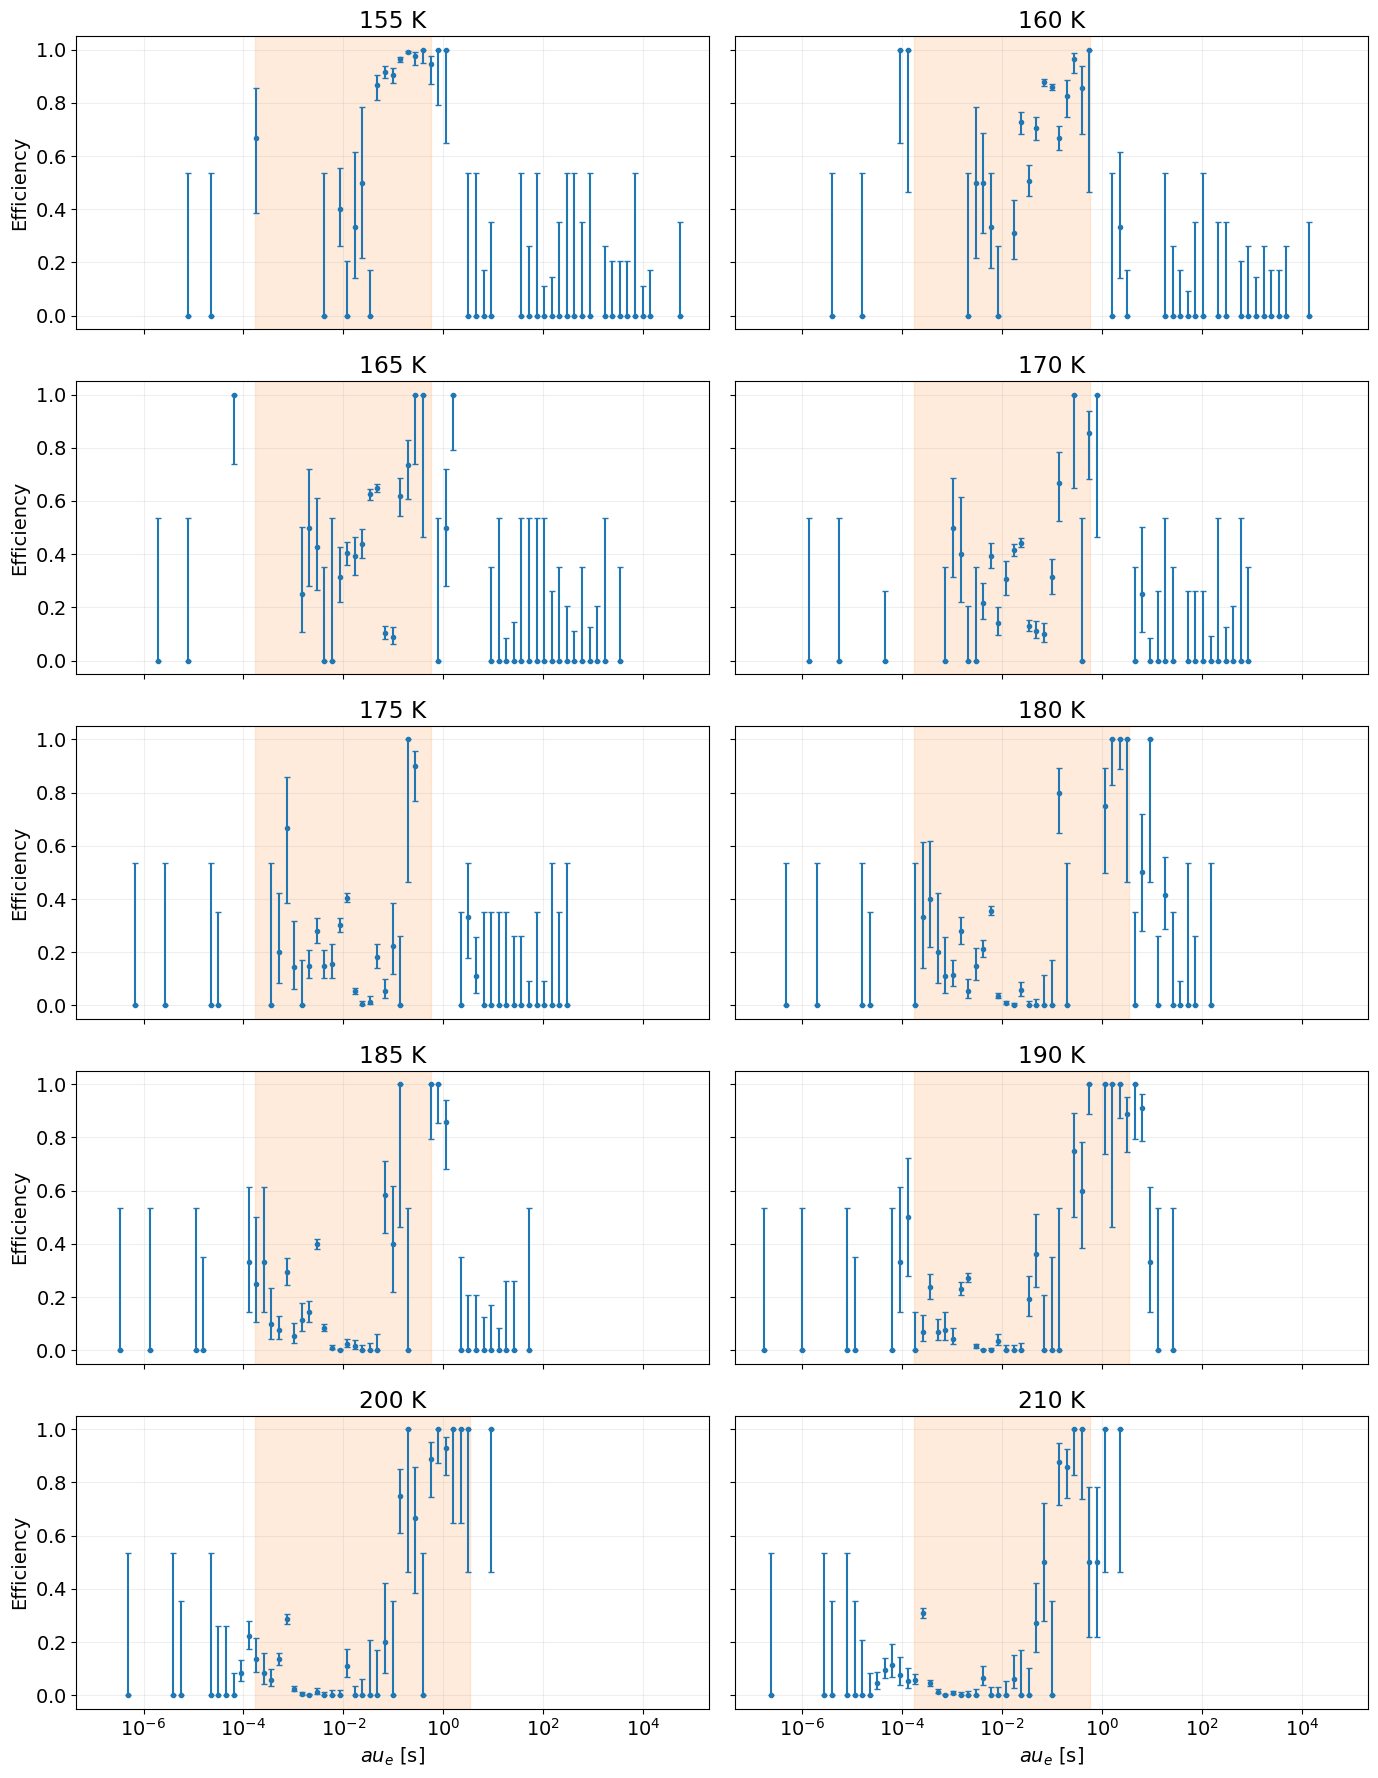

In [ ]:
measured_fine, total_fine, eff_fine, eff_lo_fine, eff_hi_fine = build_efficiency_matrices(records, measurement_temperatures, fine_tau_bins)
fine_centers = np.sqrt(fine_tau_bins[:-1] * fine_tau_bins[1:])

selected_temperatures = [155, 160, 165, 170, 175, 180, 185, 190, 200, 210]
fig, axes = plt.subplots(5, 2, figsize=(14, 18), sharex=True, sharey=True)
axes = axes.ravel()
for ax, temp in zip(axes, selected_temperatures):
    ti = np.where(measurement_temperatures == temp)[0][0]
    valid = total_fine[ti] > 0
    yerr = np.vstack([
        np.maximum(eff_fine[ti, valid] - eff_lo_fine[ti, valid], 0.0),
        np.maximum(eff_hi_fine[ti, valid] - eff_fine[ti, valid], 0.0),
    ])
    ax.errorbar(fine_centers[valid], eff_fine[ti, valid], yerr=yerr, fmt='o', ms=3, capsize=2)
    seconds = tph_grids[temp]
    ax.axvspan(seconds.min()/response_x_peak, seconds.max()/response_x_peak, color='tab:orange', alpha=0.15, label='peak-response tau range')
    ax.set_title(f'{temp} K')
    ax.set_xscale('log')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.2)
axes[-2].set_xlabel('$\\tau_e$ [s]')
axes[-1].set_xlabel('$\\tau_e$ [s]')
for ax in axes[::2]:
    ax.set_ylabel('Efficiency')
plt.tight_layout()
plt.show()


Interpretation guide for the per-temperature panels:

If the protocol window were the only effect, the high-efficiency region would look like one broad plateau within the orange band, with a drop at small tau and a drop at large tau. The plateau can shift at temperatures with the longer `t_ph` scan, but it should not fragment into unrelated peaks at fixed protocol settings.

If a short-tau feature is present only at some temperatures, or if the same tau bin has high efficiency at one temperature and low efficiency at a neighboring temperature, that is evidence for a temperature-dependent analysis selection rather than a purely physical `tau_e` acceptance.

Use these panels to identify suspicious temperatures or tau ranges before trusting a pooled curve. In particular, compare 160 K, 165 K, and 170 K: they share the same nominal `t_ph` range, so large differences among them should not be interpreted as a true one-dimensional efficiency in `tau_e`.

## 4. Efficiency heatmap in `(T, tau_e)`

This heatmap is the same information as the per-temperature panels, but arranged as a two-dimensional map. The x-axis is predicted `tau_e(T)`, the y-axis is measurement temperature, and the color is the empirical efficiency in that `(T, tau)` bin.

Why make this plot: it directly tests the assumption behind a pooled `epsilon(tau_e)`. A pooled curve assumes that efficiency is mostly a function of tau and not temperature. In the heatmap, that would look like vertical bands: the same color at a given tau across many temperatures.

How to read it: vertical structure means `epsilon` is mostly tau-dependent. Horizontal or diagonal structure means temperature and the trap population trajectory matter. Empty or noisy cells reflect bins with few trap-temperature entries.

Main takeaway: if there are strong temperature bands or patchy structures, then collapsing to one curve `epsilon(tau_e)` is losing important information and can manufacture features such as the apparent short-tau mini peak.

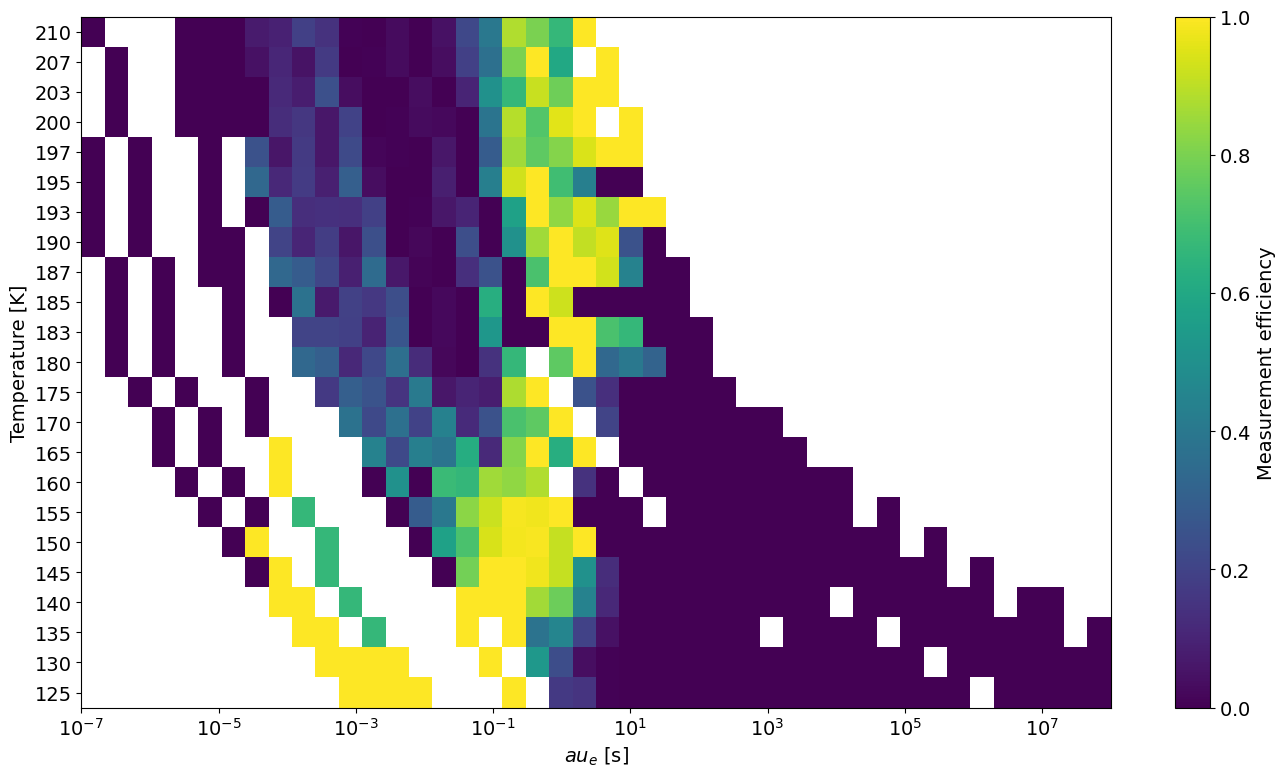

In [ ]:
measured_coarse, total_coarse, eff_coarse, eff_lo_coarse, eff_hi_coarse = build_efficiency_matrices(records, measurement_temperatures, coarse_tau_bins)
coarse_centers = np.sqrt(coarse_tau_bins[:-1] * coarse_tau_bins[1:])

masked_eff = np.ma.masked_where(total_coarse == 0, eff_coarse)
fig, ax = plt.subplots(figsize=(14, 8))
pcm = ax.pcolormesh(coarse_tau_bins, np.arange(len(measurement_temperatures) + 1), masked_eff, vmin=0, vmax=1, cmap='viridis')
ax.set_xscale('log')
ax.set_yticks(np.arange(len(measurement_temperatures)) + 0.5)
ax.set_yticklabels(measurement_temperatures)
ax.set_xlabel('$\\tau_e$ [s]')
ax.set_ylabel('Temperature [K]')
fig.colorbar(pcm, ax=ax, label='Measurement efficiency')
plt.tight_layout()
plt.show()


Interpretation guide for the raw heatmap:

Look for whether high-efficiency regions line up vertically in tau. If they do, a one-dimensional correction might be acceptable. If they do not, then the correct empirical object is `epsilon(tau_e, T)`.

The raw heatmap is intentionally not smoothed. It is useful for diagnosis, but it should not be used directly as a correction surface because sparse bins can produce artificial 0 or 1 efficiencies. The smoothed surface later in the notebook is the version intended for correction studies.

## 5. Rejection-reason heatmaps

These heatmaps break down why entries fail the direct intensity-fit selection. Fractions are relative to all characterized trap-temperature entries in that `(T, tau)` bin. A single bad point can fail multiple criteria, so these panels are diagnostic fractions, not mutually exclusive categories.

Why make this plot: if the efficiency loss were purely from the `t_ph` measurement window, rejection would mostly appear outside the orange/protocol-sensitive tau range and would not be dominated by a fit-quality statistic inside the window. If failures are dominated by `p <= 0.05` or `rel tau err > 0.5` in the middle of the window, then the efficiency curve is driven by analysis quality cuts as well as physics reach.

How to read it: bright regions identify where that criterion rejects many trap-temperature entries. Compare bright regions here to dark/low-efficiency regions in the efficiency heatmap. If they overlap, the rejection reason is likely responsible for that efficiency structure.

Main takeaway: the short-tau structure and the 160 K versus 170 K inconsistency should be interpreted through these plots. If the corresponding bins are bright in `p <= 0.05`, the issue is not absence of a signal but failure of the chosen goodness-of-fit criterion.

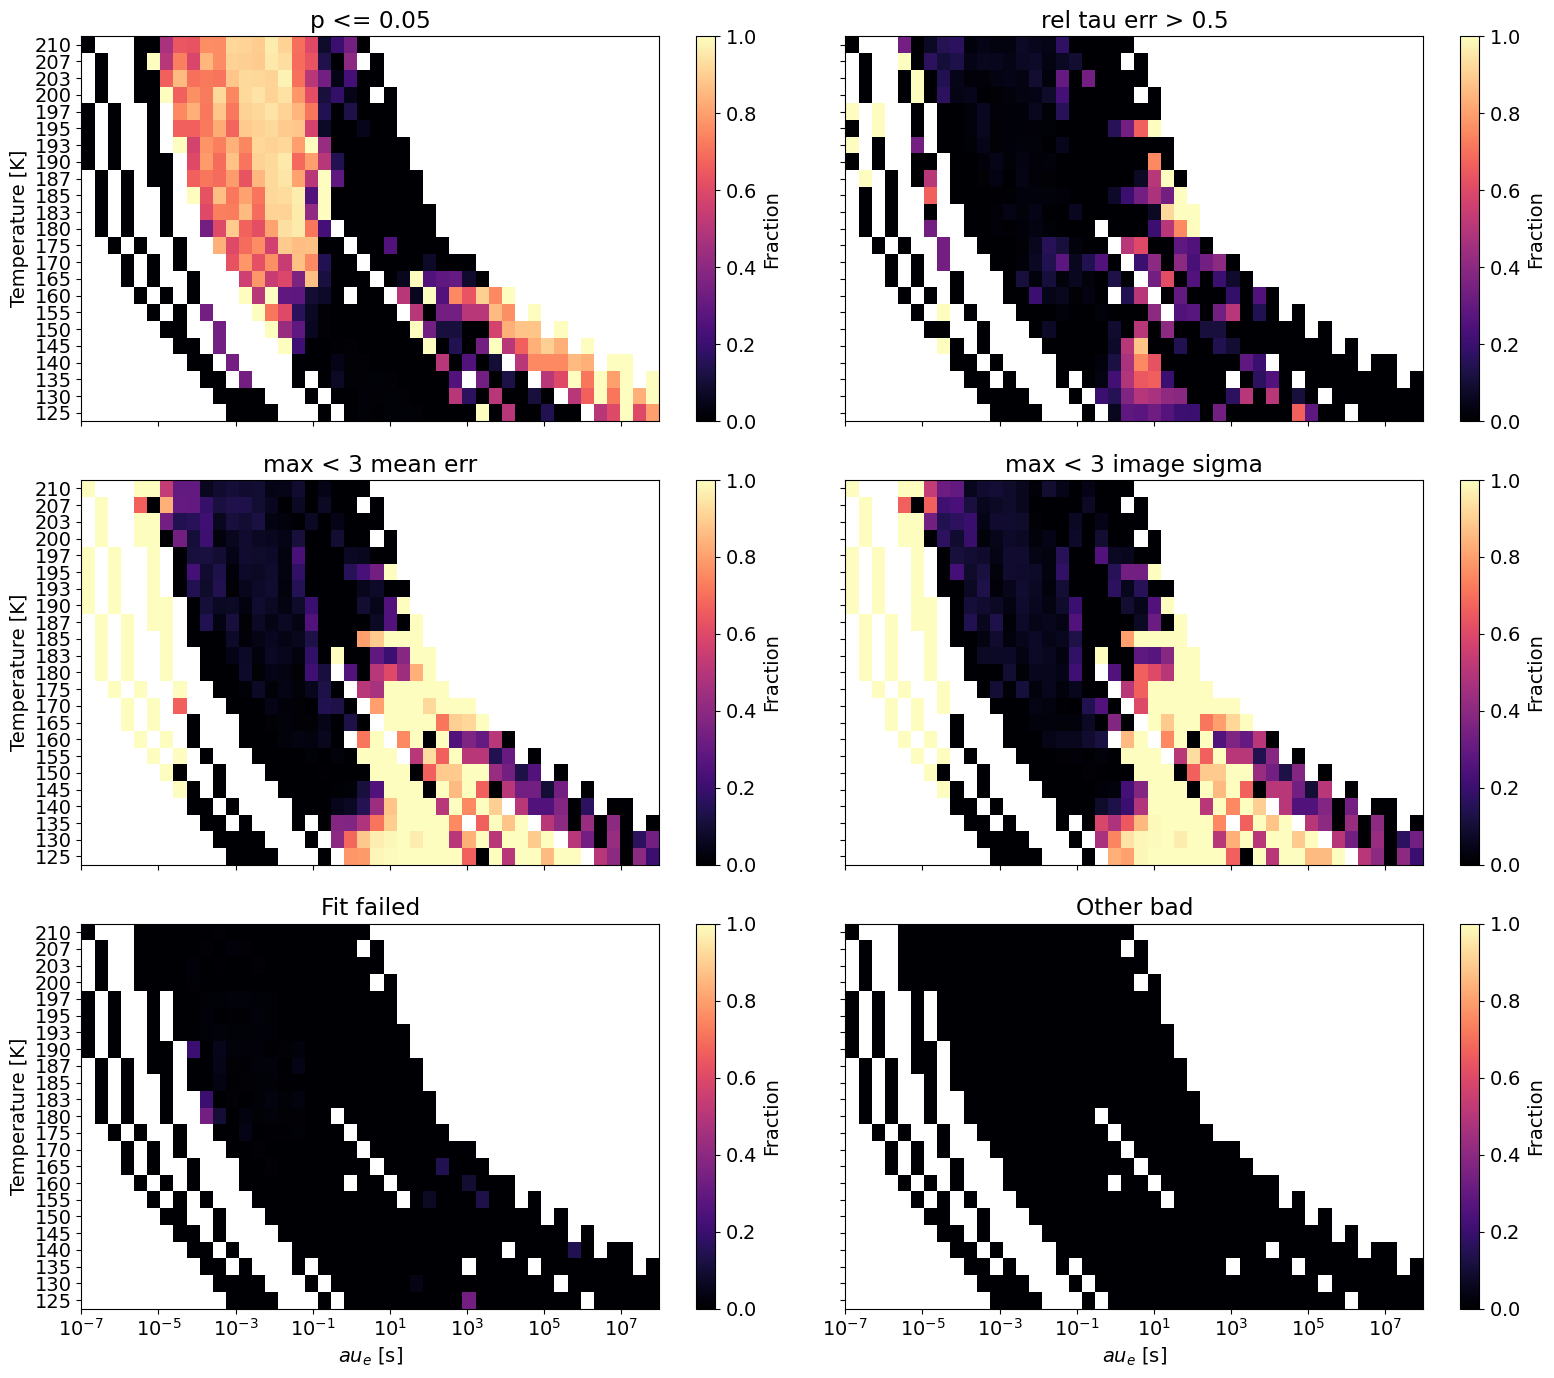

In [ ]:
reason_names = ['p <= 0.05', 'rel tau err > 0.5', 'max < 3 mean err', 'max < 3 image sigma', 'Fit failed', 'Other bad']
reason_counts = {reason: np.zeros_like(total_coarse, dtype=int) for reason in reason_names}
primary_counts = {reason: np.zeros_like(total_coarse, dtype=int) for reason in ['Good'] + reason_names}

for record in records:
    trap = record['trap']
    for ti, temp in enumerate(measurement_temperatures):
        tau = record['tau_by_temp'][ti]
        bi = np.searchsorted(coarse_tau_bins, tau, side='right') - 1
        if bi < 0 or bi >= len(coarse_tau_bins) - 1 or temp not in trap:
            continue
        primary = primary_rejection_reason(trap[temp])
        primary_counts[primary][ti, bi] += 1
        for reason, flagged in rejection_flags(trap[temp]).items():
            if flagged:
                reason_counts[reason][ti, bi] += 1

fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True, sharey=True)
axes = axes.ravel()
for ax, reason in zip(axes, reason_names):
    frac = np.divide(reason_counts[reason], total_coarse, out=np.full_like(total_coarse, np.nan, dtype=float), where=total_coarse > 0)
    masked = np.ma.masked_invalid(frac)
    pcm = ax.pcolormesh(coarse_tau_bins, np.arange(len(measurement_temperatures) + 1), masked, vmin=0, vmax=1, cmap='magma')
    ax.set_xscale('log')
    ax.set_title(reason)
    ax.set_yticks(np.arange(len(measurement_temperatures)) + 0.5)
    ax.set_yticklabels(measurement_temperatures)
    fig.colorbar(pcm, ax=ax, label='Fraction')
for ax in axes[-2:]:
    ax.set_xlabel('$\\tau_e$ [s]')
for ax in axes[::2]:
    ax.set_ylabel('Temperature [K]')
plt.tight_layout()
plt.show()


Interpretation guide for rejection reasons:

The `p <= 0.05` panel is especially important because it indicates failures of the intensity-curve model quality, not necessarily failures to see a trap. A high fraction there means many traps have fit results but are rejected because the curve does not pass the chi-squared p-value cut.

The `max < 3 mean err` and `max < 3 image sigma` panels are closer to signal-to-noise failures. Bright regions there indicate the dipole intensity is too small relative to the local noise or image fluctuations.

The `rel tau err > 0.5` panel flags cases where the fit exists but the time constant is poorly constrained. This can happen near the edges of the protocol window or when the curve shape is too flat.

If one rejection reason dominates a suspicious efficiency feature, that feature should not be called physical without checking whether the rejection criterion itself is appropriate at that temperature.

## Working interpretation: why the efficiency curves look strange

The per-temperature efficiency curves look strange because this empirical efficiency is not only measuring whether `tau_e` lies in the scanned `t_ph` window. It is measuring whether a trap-temperature entry passes the full direct-fit selection at that temperature. That selection includes model goodness-of-fit, local noise estimates, image-level noise estimates, and relative tau uncertainty.

The main mechanisms are:

1. The trap population in a tau bin changes with temperature. A fixed bin in `tau_e` at 160 K and the same bin at 170 K are not generally populated by the same traps. Each trap moves through tau space exponentially with temperature, so a tau bin at different temperatures samples different parts of the fitted trap population.

2. The denominator is conditional on the characterized sample. We evaluate every good-energy-fit trap at every temperature, even if that trap was not directly measured there. This is useful for an empirical correction, but it means the denominator includes extrapolated trap-temperature entries whose direct intensity curve at that temperature may be weak, noisy, or model-mismatched.

3. Many failures are fit-quality failures, not absence-of-signal failures. In the suspicious bins, a large fraction of rejected entries fail the intensity-fit p-value cut (`p <= 0.05`). That means the fit often exists, but the curve shape is rejected by the chi-squared criterion. This can vary strongly by temperature because of image conditions, outliers, non-Gaussian errors, imperfect intensity errors, or small model mismatches.

4. The finite-bin one-dimensional curves are noisy. At individual temperatures, many tau bins have small denominators. Bins with efficiency exactly 0 or 1 can look like sharp physics features unless they are plotted with proper binomial intervals and then smoothed or combined carefully.

5. There is a code-level caveat in `getDipoleSpectra2`: `image_sigma` is stored once when a temperature is first encountered for a trap, so it comes from the first image encountered by `glob` at that temperature rather than from each image or a stable aggregate over the temperature's images. This affects the `max(intensities) < 3 * image_sigma` cut. It does not appear to be the dominant issue in the suspicious bins we inspected, where `p <= 0.05` dominates, but it is worth fixing or at least checking in a future refit.

The practical conclusion is that the strange curves are probably not telling us there are multiple physical efficiency peaks. They are telling us that the analysis efficiency depends on both `tau_e` and temperature, and also on fit-quality behavior. This is why the smoothed two-dimensional surface `epsilon(tau_e, T)` is the better correction object.

## 6. Pooled efficiency versus per-temperature efficiency

This section quantifies how much the final corrected `tau_e(135 K)` histogram changes when efficiency is treated as pooled `epsilon(tau_e)` versus temperature-dependent `epsilon_T(tau_e)`.

Why make this comparison: visual differences in the diagnostic plots are useful, but the correction is what propagates into the physics result. If the effective corrected trap count changes substantially between pooled and per-temperature efficiencies, then the pooled correction is not just a harmless visualization choice.

Method 1: weight each trap by `1 / epsilon` evaluated at `tau` for the trap's mean measured temperature. This matches the intuitive correction that missed traps are missed near the temperature where similar traps were measured.

Method 2: weight each trap by the inverse probability of obtaining at least `well_behaved_threshold` successful temperature measurements along the full `tau(T)` curve. This is closer to correcting the global characterization selection.

Main takeaway: large differences between pooled and per-temperature Method 1 indicate that pooling is over- or under-correcting particular regions. Method 2 tends to be more stable because it uses the full temperature trajectory rather than one representative point.

In [9]:
# Pooled efficiency function.
pooled_measured = measured_coarse.sum(axis=0)
pooled_total = total_coarse.sum(axis=0)
pooled_eff, pooled_lo, pooled_hi = efficiency_from_counts(pooled_measured, pooled_total)
pooled_eff_func, pooled_interp_mask = make_log_efficiency_function(coarse_centers, pooled_eff, pooled_total, min_total=20, eff_floor=0.05)

# Per-temperature efficiency functions. Use a lower min_total because each temperature has fewer entries.
temp_eff_funcs = {}
for ti, temp in enumerate(measurement_temperatures):
    func, mask = make_log_efficiency_function(coarse_centers, eff_coarse[ti], total_coarse[ti], min_total=8, eff_floor=0.05)
    temp_eff_funcs[temp] = func

def efficiency_at_tau_and_temp(tau, temp):
    values = []
    valid_temps = []
    for grid_temp in measurement_temperatures:
        func = temp_eff_funcs[grid_temp]
        if func is None:
            continue
        values.append(float(func(np.array([tau]))[0]))
        valid_temps.append(grid_temp)
    if len(values) == 0:
        return np.nan
    return float(np.interp(temp, valid_temps, values))

def correction_histograms(records, use_temperature_dependent_efficiency=False):
    tau_raw = []
    method1_tau = []
    method1_weight = []
    method2_tau = []
    method2_weight = []

    for record in records:
        tau_135 = record['tau_135']
        tau_raw.append(tau_135)
        mean_measured_temp = np.mean(record['measured_temps'])
        tau_mean = np.exp(log_energy_cross_section(mean_measured_temp, record['energy'], record['log_sigma']))

        if use_temperature_dependent_efficiency:
            eff_mean = efficiency_at_tau_and_temp(tau_mean, mean_measured_temp)
        else:
            eff_mean = float(pooled_eff_func(np.array([tau_mean]))[0])
        if np.isfinite(eff_mean) and eff_mean > 0:
            method1_tau.append(tau_135)
            method1_weight.append(1.0 / eff_mean)

        probs = []
        for ti, temp in enumerate(measurement_temperatures):
            tau_t = record['tau_by_temp'][ti]
            if use_temperature_dependent_efficiency:
                probs.append(efficiency_at_tau_and_temp(tau_t, temp))
            else:
                probs.append(float(pooled_eff_func(np.array([tau_t]))[0]))
        p_char = poisson_binomial_at_least(probs, well_behaved_threshold)
        if np.isfinite(p_char) and p_char > 0:
            method2_tau.append(tau_135)
            method2_weight.append(1.0 / p_char)

    return {
        'raw': np.histogram(tau_raw, bins=fine_tau_bins)[0],
        'method1': np.histogram(method1_tau, bins=fine_tau_bins, weights=method1_weight)[0],
        'method2': np.histogram(method2_tau, bins=fine_tau_bins, weights=method2_weight)[0],
        'method1_weight_sum': np.sum(method1_weight),
        'method2_weight_sum': np.sum(method2_weight),
    }

pooled_corrections = correction_histograms(records, use_temperature_dependent_efficiency=False)
temp_dependent_corrections = correction_histograms(records, use_temperature_dependent_efficiency=True)
print(f'Pooled Method 1 effective count: {pooled_corrections["method1_weight_sum"]:.1f}')
print(f'Per-temperature Method 1 effective count: {temp_dependent_corrections["method1_weight_sum"]:.1f}')
print(f'Pooled Method 2 effective count: {pooled_corrections["method2_weight_sum"]:.1f}')
print(f'Per-temperature Method 2 effective count: {temp_dependent_corrections["method2_weight_sum"]:.1f}')


Pooled Method 1 effective count: 4120.2
Per-temperature Method 1 effective count: 3267.2
Pooled Method 2 effective count: 2238.9
Per-temperature Method 2 effective count: 2155.4


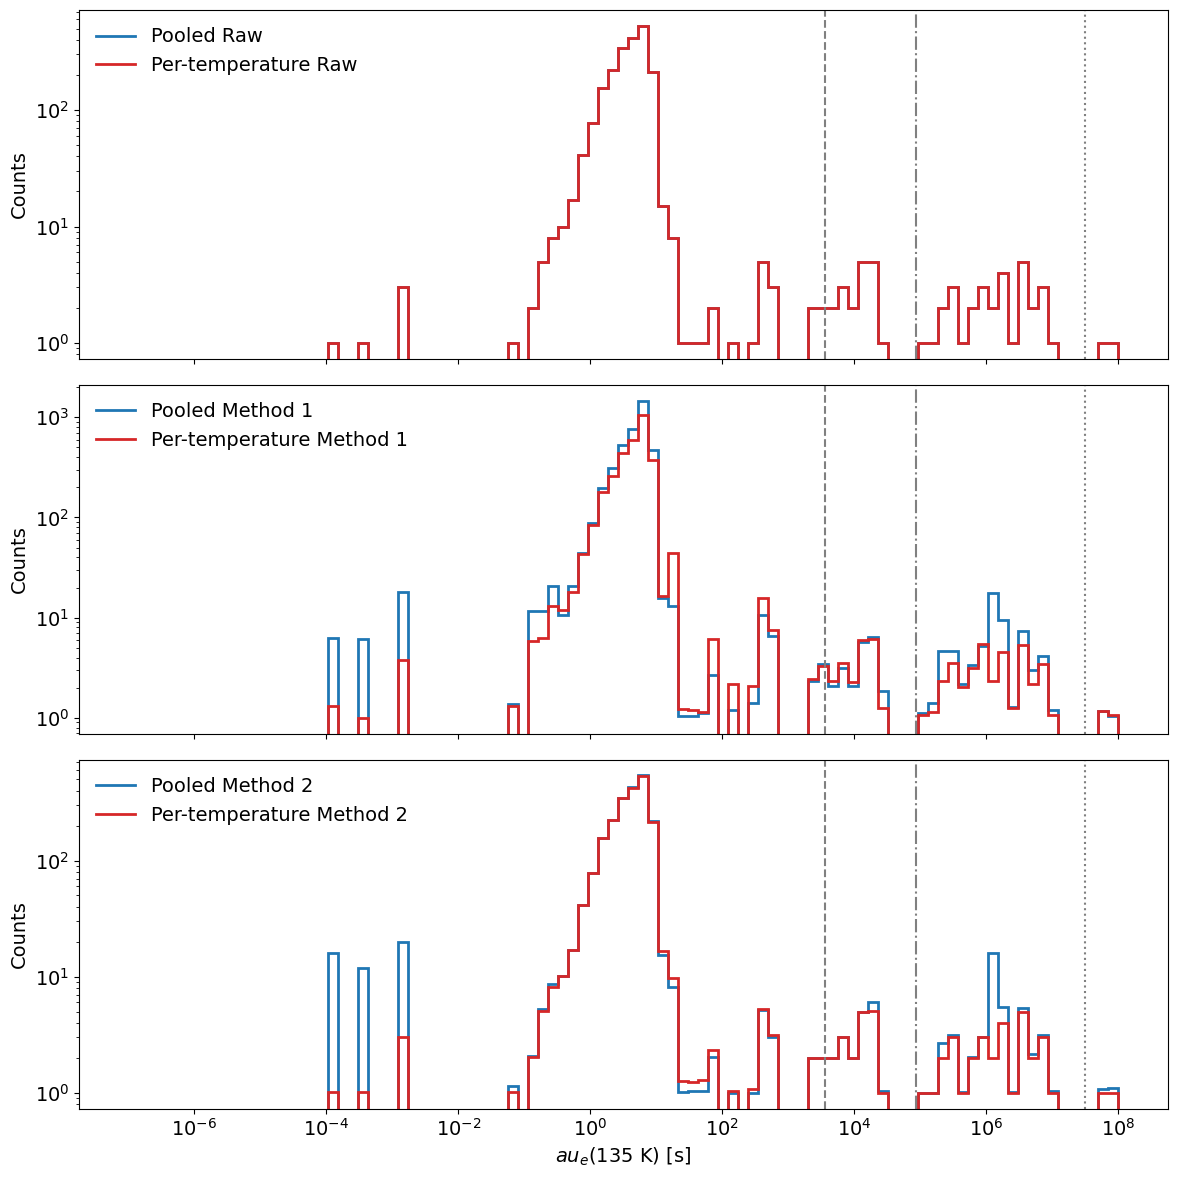

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
labels = [('raw', 'Raw'), ('method1', 'Method 1'), ('method2', 'Method 2')]
for ax, (key, label) in zip(axes, labels):
    ax.stairs(pooled_corrections[key], fine_tau_bins, lw=2, color='tab:blue', label=f'Pooled {label}')
    ax.stairs(temp_dependent_corrections[key], fine_tau_bins, lw=2, color='tab:red', label=f'Per-temperature {label}')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel('Counts')
    ax.legend(frameon=False)
    ax.axvline(3600, ls='--', color='0.5')
    ax.axvline(3600*24, ls='-.', color='0.5')
    ax.axvline(3600*24*365, ls=':', color='0.5')
axes[-1].set_xlabel('$\\tau_e(135~\mathrm{K})$ [s]')
plt.tight_layout()
plt.show()


Interpretation guide for the pooled-versus-per-temperature correction plot:

The top panel should match between pooled and per-temperature corrections because the raw characterized trap sample is the same. Differences in the lower panels come only from the efficiency model.

If pooled Method 1 lies well above per-temperature Method 1, the pooled `epsilon(tau)` is assigning too-low efficiencies to traps whose relevant measurement temperatures actually had better efficiency. That inflates the correction.

If Method 2 is much less sensitive to pooled versus per-temperature treatment, that is evidence that the global characterization probability is less affected by local artifacts in the pooled curve. It does not prove Method 2 is correct, but it makes it a useful robustness check.

## 7. Build a smoothed empirical efficiency surface `epsilon(tau, T)`

The physically relevant empirical object is the probability that a characterized trap-temperature entry passes the direct intensity-fit selection, conditional on the trap's predicted `tau_e(T)` and the measurement temperature. We estimate this as a smoothed binomial surface in `(log10(tau_e), T)`.

This is still an analysis efficiency, not a pure protocol acceptance. It includes the finite `t_ph` range, SNR, image conditions, and fit-quality cuts. The smoothing avoids treating sparse bins with efficiency exactly 0 or 1 as sharp physical features.

Why smooth: the raw two-dimensional efficiency grid has limited statistics in many `(T, tau)` bins. Directly using those bins would make the correction depend on statistical noise and bin-edge choices. The smoothed surface uses nearby bins in both temperature and log tau to estimate a local binomial efficiency.

What the smoothing parameters mean: `logtau_bandwidth=0.28` dex averages over a modest range in emission time, and `temp_bandwidth=6 K` averages mostly over neighboring temperatures. These values are intentionally local enough to preserve temperature dependence but broad enough to suppress one-bin artifacts.

Takeaway: this surface is the recommended object to use for subsequent correction studies, because it encodes the empirically observed dependence on both `tau_e` and `T`.

In [11]:
from scipy.interpolate import RegularGridInterpolator

def smooth_binomial_efficiency_surface(
    measured_counts,
    total_counts,
    tau_bins,
    temperatures,
    tau_eval,
    temp_eval,
    logtau_bandwidth=0.28,
    temp_bandwidth=6.0,
    prior_strength=1.0,
    eff_floor=0.02,
):
    bin_centers = np.sqrt(tau_bins[:-1] * tau_bins[1:])
    log_bin_centers = np.log10(bin_centers)
    log_tau_eval = np.log10(tau_eval)
    temperatures = np.asarray(temperatures, dtype=float)
    temp_eval = np.asarray(temp_eval, dtype=float)

    efficiency = np.full((len(temp_eval), len(tau_eval)), np.nan, dtype=float)
    local_total = np.zeros_like(efficiency)
    local_measured = np.zeros_like(efficiency)
    effective_n = np.zeros_like(efficiency)

    for ti, temp in enumerate(temp_eval):
        temp_weights = np.exp(-0.5 * ((temperatures - temp) / temp_bandwidth) ** 2)
        for xi, log_tau in enumerate(log_tau_eval):
            tau_weights = np.exp(-0.5 * ((log_bin_centers - log_tau) / logtau_bandwidth) ** 2)
            weights = temp_weights[:, None] * tau_weights[None, :]
            weighted_total = np.sum(weights * total_counts)
            weighted_measured = np.sum(weights * measured_counts)
            local_total[ti, xi] = weighted_total
            local_measured[ti, xi] = weighted_measured

            # Kish-style effective sample size for weighted binomial diagnostics.
            weighted_trials = weights * total_counts
            if np.sum(weighted_trials**2) > 0:
                effective_n[ti, xi] = weighted_total**2 / np.sum(weighted_trials**2)

            efficiency[ti, xi] = (weighted_measured + 0.5 * prior_strength) / (weighted_total + prior_strength)

    efficiency = np.clip(efficiency, eff_floor, 1.0)
    return {
        'tau_eval': tau_eval,
        'log_tau_eval': log_tau_eval,
        'temp_eval': temp_eval,
        'efficiency': efficiency,
        'local_total': local_total,
        'local_measured': local_measured,
        'effective_n': effective_n,
        'logtau_bandwidth': logtau_bandwidth,
        'temp_bandwidth': temp_bandwidth,
        'prior_strength': prior_strength,
        'eff_floor': eff_floor,
    }

def make_surface_interpolator(surface):
    interpolator = RegularGridInterpolator(
        (surface['temp_eval'], surface['log_tau_eval']),
        surface['efficiency'],
        bounds_error=False,
        fill_value=None,
    )

    def epsilon_tau_T(tau, temp):
        tau = np.asarray(tau, dtype=float)
        temp = np.asarray(temp, dtype=float)
        tau_b, temp_b = np.broadcast_arrays(tau, temp)
        log_tau = np.log10(np.clip(tau_b, surface['tau_eval'][0], surface['tau_eval'][-1]))
        temp_clipped = np.clip(temp_b, surface['temp_eval'][0], surface['temp_eval'][-1])
        points = np.column_stack([temp_clipped.ravel(), log_tau.ravel()])
        values = interpolator(points).reshape(tau_b.shape)
        return np.clip(values, surface['eff_floor'], 1.0)

    return epsilon_tau_T

surface_tau_grid = np.geomspace(1e-7, 1e8, 220)
surface_temp_grid = np.linspace(measurement_temperatures.min(), measurement_temperatures.max(), 140)

epsilon_surface = smooth_binomial_efficiency_surface(
    measured_coarse,
    total_coarse,
    coarse_tau_bins,
    measurement_temperatures,
    surface_tau_grid,
    surface_temp_grid,
    logtau_bandwidth=0.28,
    temp_bandwidth=6.0,
    prior_strength=1.0,
    eff_floor=0.02,
)
epsilon_tau_T = make_surface_interpolator(epsilon_surface)

np.savez(
    'epsilon_tau_temperature_surface.npz',
    tau_eval=epsilon_surface['tau_eval'],
    temp_eval=epsilon_surface['temp_eval'],
    efficiency=epsilon_surface['efficiency'],
    local_total=epsilon_surface['local_total'],
    local_measured=epsilon_surface['local_measured'],
    effective_n=epsilon_surface['effective_n'],
    logtau_bandwidth=epsilon_surface['logtau_bandwidth'],
    temp_bandwidth=epsilon_surface['temp_bandwidth'],
    prior_strength=epsilon_surface['prior_strength'],
    eff_floor=epsilon_surface['eff_floor'],
)
print('Saved epsilon_tau_temperature_surface.npz')


Saved epsilon_tau_temperature_surface.npz


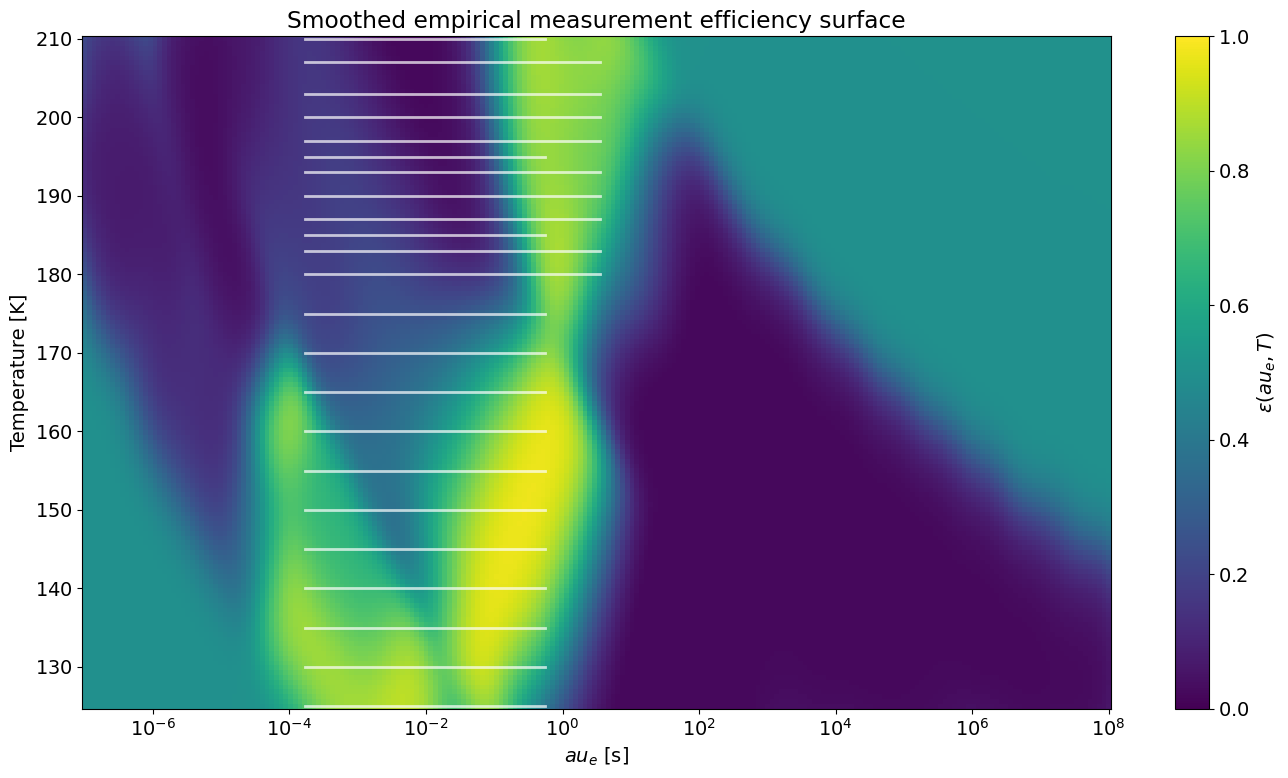

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))
pcm = ax.pcolormesh(
    epsilon_surface['tau_eval'],
    epsilon_surface['temp_eval'],
    epsilon_surface['efficiency'],
    vmin=0,
    vmax=1,
    cmap='viridis',
    shading='auto',
)
ax.set_xscale('log')
ax.set_xlabel('$\\tau_e$ [s]')
ax.set_ylabel('Temperature [K]')
fig.colorbar(pcm, ax=ax, label='$\epsilon(\tau_e, T)$')

for temp in measurement_temperatures:
    seconds = tph_grids.get(temp)
    if seconds is None:
        continue
    ax.plot([seconds.min()/response_x_peak, seconds.max()/response_x_peak], [temp, temp], color='white', lw=2, alpha=0.7)

ax.set_title('Smoothed empirical measurement efficiency surface')
plt.tight_layout()
plt.show()


Interpretation guide for the smoothed `epsilon(tau,T)` heatmap:

The color is the smoothed empirical probability that a trap-temperature entry passes the direct intensity-fit selection. The white horizontal line segments show the approximate tau range where each temperature's `t_ph` grid samples the peak response.

A physically reasonable surface should have high efficiency mostly near the protocol-sensitive tau range and low efficiency far outside it. However, because this is an analysis efficiency, it can also show temperature-dependent depressions inside the protocol window if image quality or fit-quality cuts reject many entries at that temperature.

Use this plot as the main visual representation of `epsilon(tau,T)`. If the high-efficiency band is not vertical, then a one-dimensional `epsilon(tau)` is not adequate.

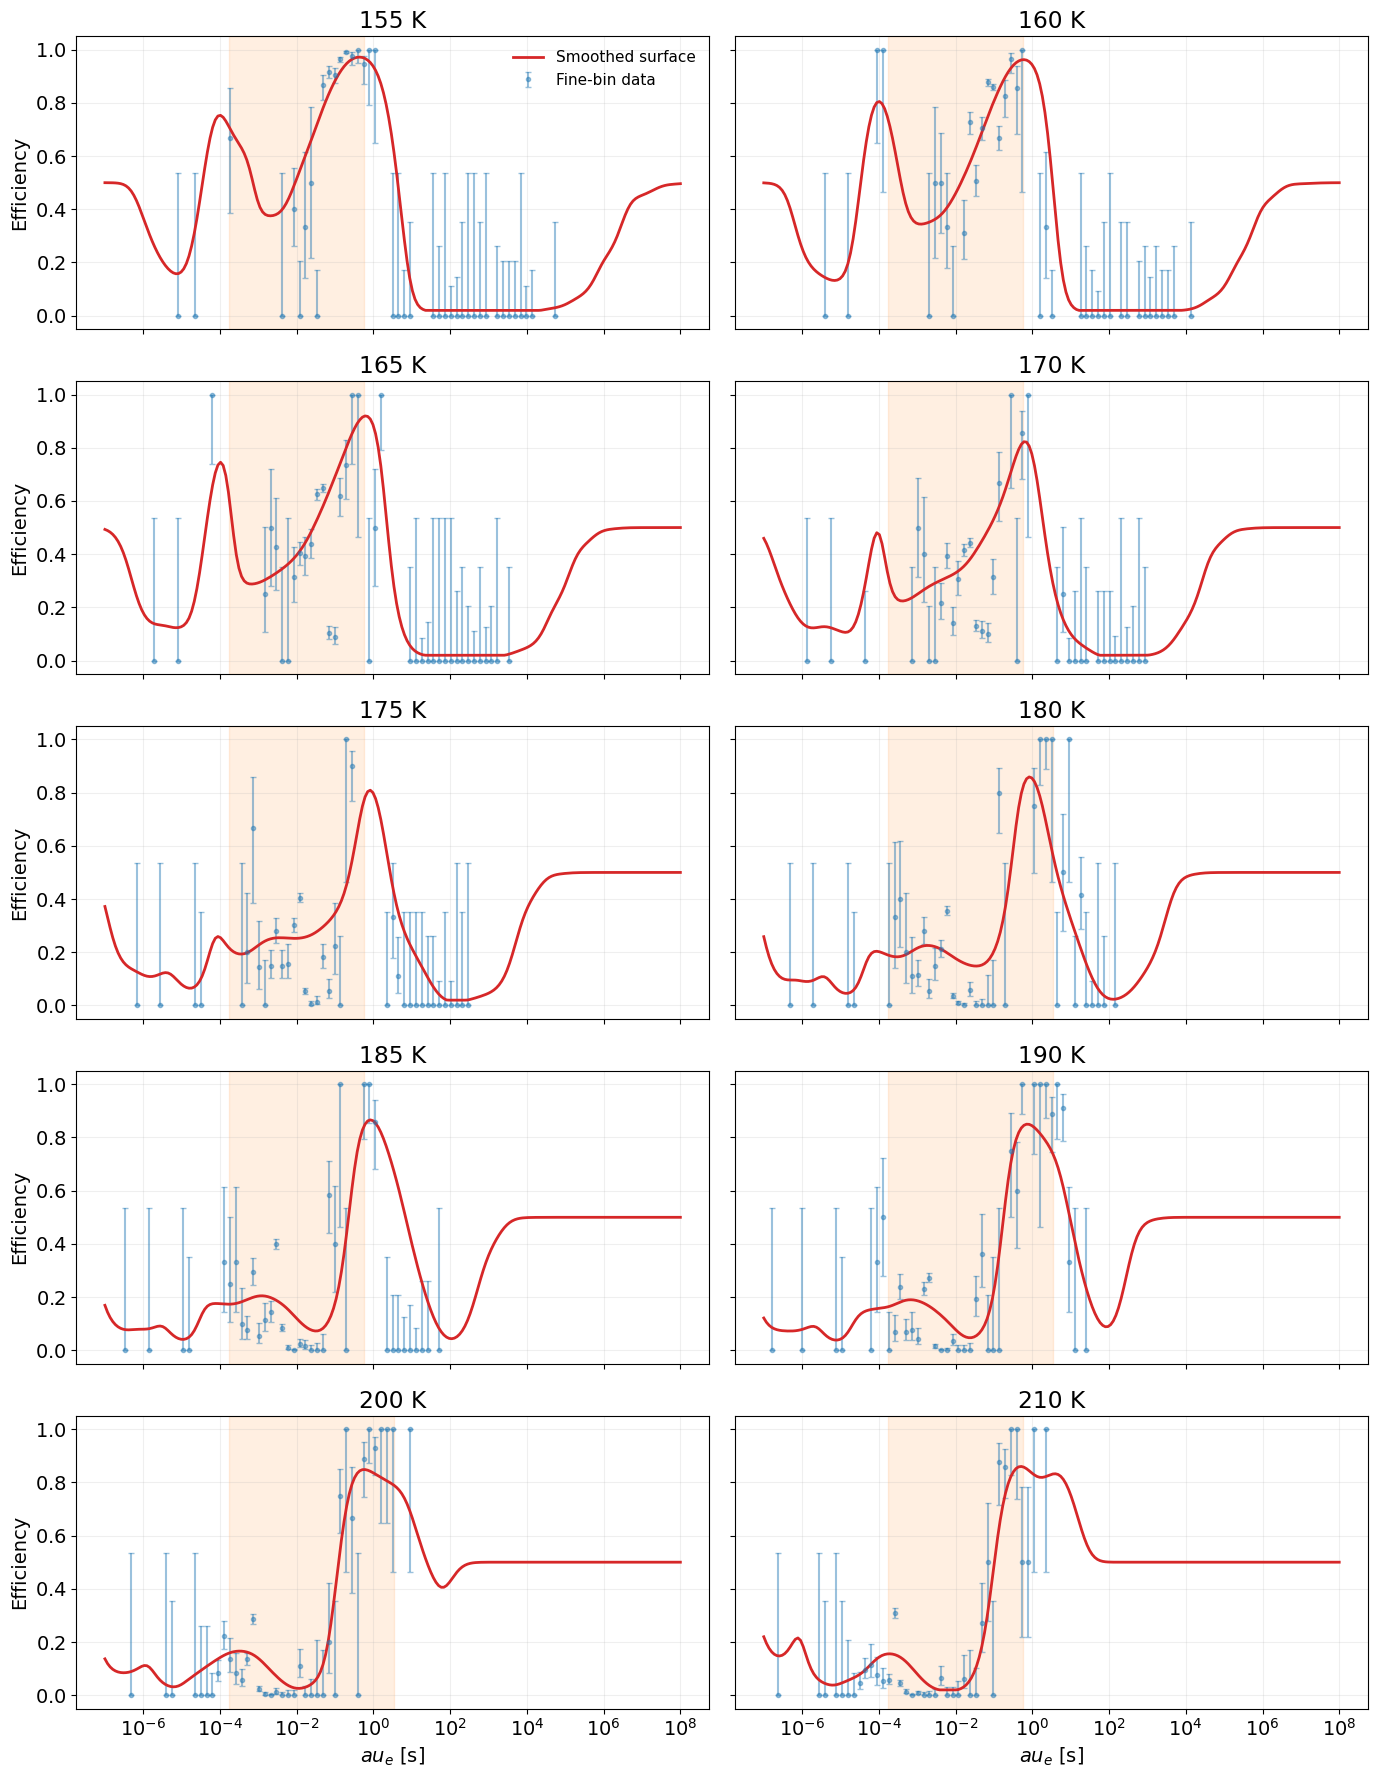

In [ ]:
selected_temperatures = [155, 160, 165, 170, 175, 180, 185, 190, 200, 210]
fig, axes = plt.subplots(5, 2, figsize=(14, 18), sharex=True, sharey=True)
axes = axes.ravel()
for ax, temp in zip(axes, selected_temperatures):
    ti = np.where(measurement_temperatures == temp)[0][0]
    valid = total_fine[ti] > 0
    yerr = np.vstack([
        np.maximum(eff_fine[ti, valid] - eff_lo_fine[ti, valid], 0.0),
        np.maximum(eff_hi_fine[ti, valid] - eff_fine[ti, valid], 0.0),
    ])
    ax.errorbar(fine_centers[valid], eff_fine[ti, valid], yerr=yerr, fmt='o', ms=3, capsize=2, alpha=0.45, label='Fine-bin data')
    ax.plot(surface_tau_grid, epsilon_tau_T(surface_tau_grid, temp), color='tab:red', lw=2, label='Smoothed surface')
    seconds = tph_grids[temp]
    ax.axvspan(seconds.min()/response_x_peak, seconds.max()/response_x_peak, color='tab:orange', alpha=0.12)
    ax.set_title(f'{temp} K')
    ax.set_xscale('log')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.2)
axes[0].legend(frameon=False, fontsize=11)
axes[-2].set_xlabel('$\\tau_e$ [s]')
axes[-1].set_xlabel('$\\tau_e$ [s]')
for ax in axes[::2]:
    ax.set_ylabel('Efficiency')
plt.tight_layout()
plt.show()


Interpretation guide for the surface-overlaid per-temperature curves:

The black points are the original fine-bin efficiency estimates with Jeffreys intervals. The red curve is the value of the smoothed two-dimensional surface at that temperature.

This plot is a sanity check on the smoothing. The red curve should follow the broad trend of the data without chasing isolated 0 or 1 bins. If it misses a stable feature seen across many adjacent bins, the smoothing bandwidth may be too large. If it follows every noisy fluctuation, the bandwidth is too small.

The goal is not to make every point lie on the red curve. The goal is to produce a correction surface that captures robust efficiency structure while suppressing finite-statistics artifacts.

## 8. Use `epsilon(tau,T)` for the correction

Method 1 evaluates the surface at `tau(T_mean measured), T_mean measured`. Method 2 evaluates the surface at every measured temperature point along each trap's fitted `tau(T)` curve and computes the probability of obtaining at least `well_behaved_threshold` good temperature fits.

Why this matters: the final physics object is the inferred distribution of `tau_e(135 K)`. The raw histogram contains only traps that were characterized well enough to fit `tau(T)`. The correction estimates how many similar traps could have been missed by the same analysis selection.

Method 1 interpretation: each observed trap stands in for traps missed near the emission time and temperature where this trap was typically measured. This is intuitive and relatively easy to explain, but it compresses a trap's full measurement history into one representative temperature.

Method 2 interpretation: each observed trap is weighted by the inverse probability that the entire temperature scan would characterize it. This better matches the actual selection `at least four good temperature fits`, but it depends on the assumption that the per-temperature efficiencies can be combined approximately as independent Bernoulli probabilities.

Recommended use: treat Method 1 and Method 2 as complementary. If they agree, the correction is robust. If they disagree, Method 2 is usually closer to the selection function, while Method 1 is a conservative local-efficiency correction.

In [14]:
def surface_correction_histograms(records):
    tau_raw = []
    method1_tau = []
    method1_weight = []
    method1_eff = []
    method2_tau = []
    method2_weight = []
    method2_prob = []

    for record in records:
        tau_135 = record['tau_135']
        tau_raw.append(tau_135)
        mean_measured_temp = np.mean(record['measured_temps'])
        tau_mean = np.exp(log_energy_cross_section(mean_measured_temp, record['energy'], record['log_sigma']))
        eff_mean = float(epsilon_tau_T(tau_mean, mean_measured_temp))
        if np.isfinite(eff_mean) and eff_mean > 0:
            method1_tau.append(tau_135)
            method1_weight.append(1.0 / eff_mean)
            method1_eff.append(eff_mean)

        per_temperature_prob = epsilon_tau_T(record['tau_by_temp'], measurement_temperatures)
        p_characterized = poisson_binomial_at_least(per_temperature_prob, well_behaved_threshold)
        if np.isfinite(p_characterized) and p_characterized > 0:
            method2_tau.append(tau_135)
            method2_weight.append(1.0 / p_characterized)
            method2_prob.append(p_characterized)

    return {
        'raw': np.histogram(tau_raw, bins=fine_tau_bins)[0],
        'method1': np.histogram(method1_tau, bins=fine_tau_bins, weights=method1_weight)[0],
        'method2': np.histogram(method2_tau, bins=fine_tau_bins, weights=method2_weight)[0],
        'method1_weight_sum': np.sum(method1_weight),
        'method2_weight_sum': np.sum(method2_weight),
        'method1_eff': np.asarray(method1_eff),
        'method2_prob': np.asarray(method2_prob),
    }

surface_corrections = surface_correction_histograms(records)
print(f'Smoothed epsilon(tau,T) Method 1 effective count: {surface_corrections["method1_weight_sum"]:.1f}')
print(f'Smoothed epsilon(tau,T) Method 2 effective count: {surface_corrections["method2_weight_sum"]:.1f}')
print(f'Median Method 1 efficiency: {np.median(surface_corrections["method1_eff"]):.3f}')
print(f'Median Method 2 characterization probability: {np.median(surface_corrections["method2_prob"]):.3f}')


Smoothed epsilon(tau,T) Method 1 effective count: 3501.9
Smoothed epsilon(tau,T) Method 2 effective count: 2158.2
Median Method 1 efficiency: 0.941
Median Method 2 characterization probability: 0.991


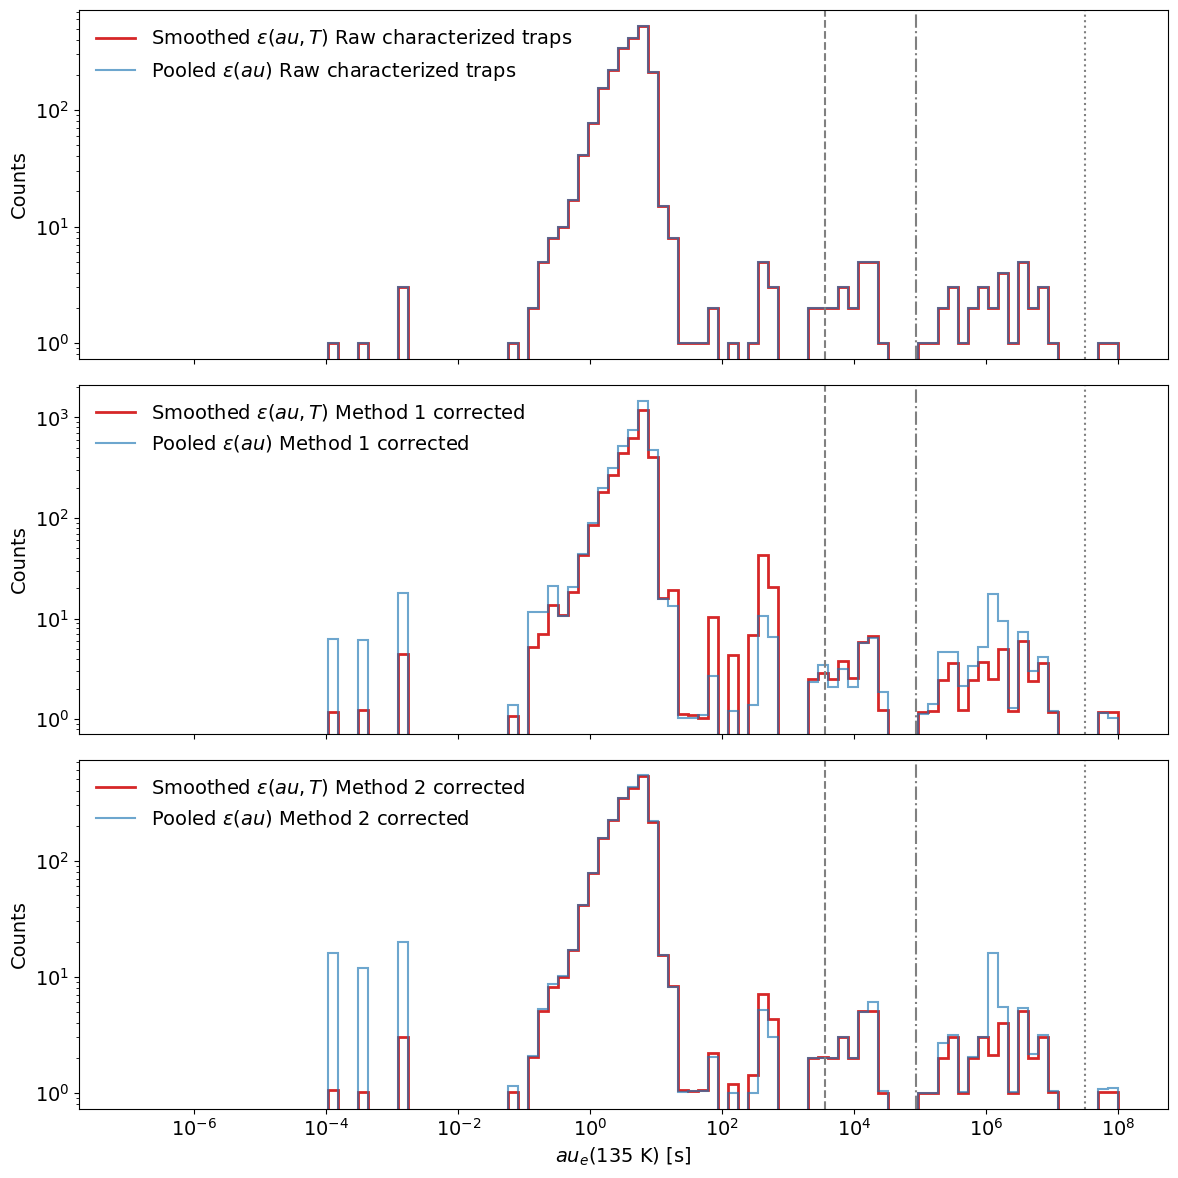

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
plot_specs = [
    ('raw', 'Raw characterized traps'),
    ('method1', 'Method 1 corrected'),
    ('method2', 'Method 2 corrected'),
]
for ax, (key, label) in zip(axes, plot_specs):
    ax.stairs(surface_corrections[key], fine_tau_bins, color='tab:red', lw=2, label=f'Smoothed $\epsilon(\tau,T)$ {label}')
    if key in pooled_corrections:
        ax.stairs(pooled_corrections[key], fine_tau_bins, color='tab:blue', lw=1.5, alpha=0.65, label=f'Pooled $\epsilon(\tau)$ {label}')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel('Counts')
    ax.legend(frameon=False)
    ax.axvline(3600, ls='--', color='0.5')
    ax.axvline(3600*24, ls='-.', color='0.5')
    ax.axvline(3600*24*365, ls=':', color='0.5')
axes[-1].set_xlabel('$\\tau_e(135~\mathrm{K})$ [s]')
plt.tight_layout()
plt.show()


Interpretation guide for the final corrected histograms:

The top panel is a consistency check: raw counts should be identical regardless of the efficiency model. The middle and bottom panels show how the chosen efficiency model changes the inferred trap population at 135 K.

The red curves use the smoothed `epsilon(tau,T)` surface. The blue curves use the older pooled `epsilon(tau)` correction. Where red and blue differ, the pooled curve is not correctly representing the temperature-dependent selection.

If the smoothed surface reduces an artificial enhancement that was present in the pooled correction, that supports the interpretation that the pooled curve was overcorrecting because it mixed temperatures with different fit-quality behavior.

The result to propagate should be chosen based on analysis philosophy. If the goal is the best empirical selection correction, use the smoothed `epsilon(tau,T)` correction. If the goal is a deliberately conservative bound, compare against the pooled correction as a systematic variation rather than treating it as the central result.